# <u>Convolutional Neural Network (CNN)</u>

### Prerequisites:
* <a href="../Artificial Neural Networks/Neural Networks.ipynb">Check out the notebook on Neural Networks</a>

## Topics

* [0. Introduction](#intro)
* [1. Convolutional Operation](#op)
* [2. Properties of Convolution](#prop)
* [3. CNN Components](#comp)
* [4. CNN Applications](#app)
* [5. 1D / 2D / 3D Convolutions](#1D2D3D)
* [6. Important Types of Convolutions](#important)
* [7. Separable Convolutions and Flattening](#separable)
* [8. Modern Architectures ](#1)
* [9. CNN Implementation](#impl)
* [10. CNN PyTorch](#py)
* [11. CNN TensorFlow](#tensor)


In [ ]:
import numpy as np # for random numbers and numpy arrays
import pandas as pd # for dataframes
import matplotlib.pyplot as plt # for 2D Plots

import torch
import torchvision
import torchvision.transforms as transforms

print("Setup complete")

100%|██████████| 170M/170M [13:25<00:00, 212kB/s]  


Setup complete


In [ ]:
image = np.array([
    [3, 3, 2, 1],
    [0, 0, 1, 3],
    [3, 1, 2, 2],
    [2, 0, 0, 2]
])

kernel = np.array([
    [0, 1, 2],
    [2, 2, 0],
    [0, 1, 2]
])

stride = 1
k = kernel.shape[0]

output_size = (image.shape[0] - k) // stride + 1
output = np.zeros((output_size, output_size))

for i in range(output_size):
    for j in range(output_size):
        region = image[i:i+k, j:j+k]
        output[i, j] = np.sum(region * kernel)

print(output)

[[12. 12.]
 [10. 17.]]


In [38]:
image = np.array([
    [3, 3, 2, 1],
    [0, 0, 1, 3],
    [3, 1, 2, 2],
    [2, 0, 0, 2]
])

kernel = np.array([
    [0, 1, 2],
    [2, 2, 0],
    [0, 1, 2]
])

stride = 1
k = kernel.shape[0]

output_size = (image.shape[0] - kernel.shape[0]) // stride + 1
output_vec = []

for row in range(output_size):
    for col in range(output_size):
        region = image[row:row+k, col:col+k]
        output_vec.append(np.sum(region * kernel))

output = np.array(output_vec).reshape(output_size, output_size)

print(output)

[[12 12]
 [10 17]]


<a class="anchor" id="intro"></a>

# 0. Introduction

### <u>1. What are CNNs?</u>

- CNNs are a class of deep neural networks inspired by the human visual cortex
- They process data with a spatial structure (such as images) by learning hierarchical features automatically
- Early layers learn simple features (e.g., edges), while deeper layers learn more complex patterns (e.g., shapes and objects)

### <u>2. Common applications</u>

* Image classification – assigning labels to images
* Object detection and localization – identifying and locating objects
* Semantic segmentation – classifying every pixel in an image
* Autonomous driving – mapping camera images directly to steering commands 
* Road segmentation from aerial imagery
* Medical imaging – COVID-19 detection and localization from CT scans
* Computational pathology – segmenting cell nuclei in microscopic images
* Image colorization – generating color versions of grayscale images
* Speech and audio analysis – emotion recognition from speech
- CNNs are also applied beyond images, including natural language processing, audio, and time-series data

### <u>3. Basic CNN architecture</u>
1. Input layer
    - Receives the raw input (image, audio, etc.)
2. Convolutional layers
    - Apply learnable filters (kernels) to extract feature maps
    - These layers detect increasingly complex features as the network gets deeper
3. Pooling layers
    - Reduce the spatial dimensions of the feature maps
    - Help retain important information while reducing computation and overfitting
4. Fully connected layers
    - Combine the extracted features to make a prediction
5. Softmax layer
    - Converts the final outputs into class probabilities for classification tasks

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/1.png" width="600"/>
</div>


<a class="anchor" id="op"></a>

# 1. Convolutional Operation

### <u>1. Filters extract features</u>

Before CNNs, computer vision relied on hand-crafted filters to detect specific image features. One of the most famous examples is the Sobel filter, which detects image edges.

##### Why edges?

Edges occur where neighboring pixel intensities change rapidly. The Sobel operator approximates the image gradient, measuring how quickly brightness changes across the image.

### <u>2. Sobel filters</u>

Given an image $A$ we apply the filters using the **convolution** $\ast$.

##### Horizontal gradient $G_x=S_x \ast A$
- Detects vertical edges:
$$
S_x = \begin{bmatrix} -1 & 0 & \color{green}1\color{white} \\ -2 & 0 & \color{green}2\color{white} \\ \color{green}-1\color{white} & \color{green}0\color{white} & \color{green}1\color{white} \end{bmatrix}
$$
$\qquad \quad$- $S_x$ is the outer product of $\underbrace{\begin{bmatrix} \color{green}1\color{white} \\ \color{green}2\color{white} \\ \color{green}1\color{white} \end{bmatrix}}_{\text{averaging}} \in \mathbb{R}^{3 \times 1}$ and $\underbrace{\begin{bmatrix} \color{green}-1\color{white} & \color{green}0\color{white} & \color{green}1\color{white} \end{bmatrix}}_{\text{differentiation}} \in \mathbb{R}^{1 \times 3}$

$\qquad \quad$ - The column vector $\begin{bmatrix} 1 \\ 2 \\ 1 \end{bmatrix}$ is an averaging (or smoothing) kernel with the center value weighted more heavily

$\qquad \quad$ - Normalizing it yields $\begin{bmatrix} 1/4 \\ 2/4 \\ 1/4 \end{bmatrix}$ and it computes a weighted average of neighboring pixels

$\qquad \quad$ - Given vertical pixel values like $\begin{bmatrix} 100 \\ 110 \\ 120 \end{bmatrix}$ the weighted average is $\frac{100 + 2 \cdot 110 + 120 }{4}=110$ 

$\qquad \quad$ - So instead of looking at one noisy pixel, consider its neighbors

$\qquad \quad$ - The row vector $\begin{bmatrix} -1 & 0 & 1 \end{bmatrix}$ computes a finite difference

$\qquad \quad$ - For three neighboring pixels $\begin{bmatrix} 50 & 60 & 120 \end{bmatrix}$ it computes $-50+0+120=70$

$\qquad \quad$ - If the left and right pixels are similar, $\begin{bmatrix} 80 & 82 & 84 \end{bmatrix}$ then $-80+84=4$

$\qquad \quad$ - This kernel therefore measures how quickly the intensity changes from left to right

##### Horizontal gradient $G_y=S_y \ast A$
- Detects horizontal edges:
$$
S_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ 1 & 2 & 1 \end{bmatrix}
$$


The overall edge strength is computed as 

$$
G=\sqrt{G_x^2 + G_y^2}
$$

which combines gradients from both directions.


### <u>3. Applying a filter</u>

Images are represented as matrices of pixel values.

To apply a filter:
1. Place the filter over a small region of the image.
2. Multiply corresponding entries.
3. Sum the products.
4. Store the result in the output feature map.
5. Move the filter one position and repeat.

Applying the Sobel filter at every location creates a feature map, where high values indicate detected edges. Because the filter cannot be centered on border pixels without padding, the output is smaller than the input.


### <u>4. Connection to CNNs</u>

The key insight is that CNNs perform the same convolution operation, but with an important difference:

- Traditional computer vision uses manually designed filters like Sobel
- CNNs start with randomly initialized filters which are then applied to the input
- During training, gradient descent updates the filter weights so they learn useful features automatically


### <u>5. Images and filters in CNNs</u>

Grey scale images ...
- are matrices of dimensions $\text{Height} \times \text{Width} \times \text{Depth}$ with $\text{Depth}=1$
- have Pixel entries that differ from 0 (black) to 255 (white)

Color images ...
- are tensors of dimensions $\text{Height} \times \text{Width} \times \text{Depth}$ with $\text{Depth}=3$
- depth value denotes the RGB values (red- green- blue)

Filters ...
- are usually square
- depth value must always equal to the input's depth

**For example, a $2 \times 2$ filter applied to an RGB image actually has dimensions $2 \times 2 \times 3$.**


### <u>6. Mathematical definition of 2D convolution</u>

For a $3 \times 3 \times 1$ input 
$$
\begin{bmatrix} a & b & c \\ d & e & f \\ g & h & i \end{bmatrix}
$$

and a $2 \times 2 \times 1$ filter

$$
\begin{bmatrix} w_{11} & w_{12}  \\ w_{21} & w_{22}   \end{bmatrix}
$$

the output is a $2 \times 2 \times 1$ feature map whose entries are computed as dot products:

$$
\begin{align*}
s_{11} &= aw_{11} + bw_{12} + dw_{21} + ew_{22} \\
s_{12} &= bw_{11} + cw_{12} + ew_{21} + fw_{22} \\
s_{21} &= dw_{11} + ew_{12} + gw_{21} + hw_{22} \\
s_{22} &= ew_{11} + fw_{12} + hw_{21} + iw_{22} \\
\end{align*}
$$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/2.png" width="550"/>
  <img src="pics/3.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/4.png" width="550"/>
  <img src="pics/5.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/6.png" width="550"/>
  <img src="pics/7.png" width="550"/>
</div>



### <u>7. Key takeaways</u>
- A filter (kernel) is a small matrix that extracts specific patterns from an image.
- Traditional filters like Sobel detect edges using fixed, manually designed weights.
- Convolution slides the filter across the image, computing a dot product at each position to produce a feature map.
- CNNs use the same convolution operation, but their filters are learned automatically during training rather than manually specified.
- For color images, the filter's depth must match the image's depth (e.g., $32 \times 32 \times 3$ for RGB images).

In [ ]:
# Sobel filter




<a class="anchor" id="prop"></a>

# 2. Properties of Convolution

### <u>1. Sparse interactions</u>

Unlike a dense neural network, where every neuron is connected to every neuron in the previous layer, a convolutional layer only connects each output neuron to a small local region of the input (called the receptive field).

**Example:**
For a $3 \times 3 \times 1$ input and a $2 \times 2 \times 1$ filter:
- Each output value depends on only 4 input pixels 
- So our receptive field are 4 neurons and we apply a "local search" for featrures
- The convolution therefore creates 16 total connections

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/8.png" width="550"/>
  <img src="pics/9.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/10.png" width="550"/>
  <img src="pics/11.png" width="550"/>
</div>


- A comparable fully connected layer would require 36 connections because every hidden neuron connects to all 9 input pixels
- The receptive field of the dense network are 9 neurons
- So we apply a "global search" for features

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/12.png" width="550"/>
</div>

**Why is this useful?**

Images have strong local structure. For example, when detecting a person's eye, nearby pixels (like the face) are much more informative than pixels on the opposite side of the image. Therefore, CNNs search for features locally, while dense networks unnecessarily consider the entire image.


### <u>2. Parameter sharing</u>

One of the biggest advantages of CNNs is that the same filter weights are reused across the entire image.

Instead of learning a different set of weights for every image location, a CNN slides one filter over the input.

For example, a $2 \times 2 \times 1$ filter has only four weights:
$$
\begin{bmatrix} w_{11} & w_{12} \\ w_{21} & w_{22} \end{bmatrix}
$$
As the filter moves across the image, these same four weights are reused repeatedly.

**Comparison with dense networks**
Using the previous example:

- CNN: 4 learnable weights
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/13.png" width="550"/>
  <img src="pics/14.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/15.png" width="550"/>
  <img src="pics/16.png" width="550"/>
</div>

---
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/17.png" width="550"/>
</div>


- Dense network: 36 learnable weights

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/18.png" width="550"/>
</div>

The dense network therefore uses 9 times more parameters.

### <u>3. Why sparse connections and parameter sharing matter</u>

These two properties provide several advantages:
- Far fewer parameters to learn
- Lower memory usage
- Faster computation
- Reduced risk of overfitting, leading to better generalization
- Dense Layer: For $m$ inputs and $n$ outputs the dense net requires $m \times n$ parameters and runtime
- Convolutional layer: Requires $k \times n$ parameters and runtime, where $k \ll m$ is the much smaller receptive field

**Large-scale example**

For a $100 \times 100 \times 3$ RGB image:
- A CNN using a $5 \times 5 \times 3$ filter needs only $5 \times 5 \times 3 = 75$ parameters (bias term unconsidered)

- A comparable dense layer would require $\underbrace{(100^2 \cdot 3)}_{\text{input layer}} \cdot \underbrace{100^2}_{\text{hidden layer}} = 300.000.000$ parameters. 

This illustrates why CNNs scale much better to large images.

### <u>4. Equivariance to translation</u>

A convolutional filter searches for the same feature everywhere in the image.

If a learned feature (such as an eye or an edge) moves to a different location, the filter will still detect it because the same weights are applied at every position.

This property is called equivariance to translation. In simple terms:

- Move the object $\rightarrow$ the detected feature moves by the same amount in the feature map.

The filter does not depend on the absolute position of the feature, only on whether the local pattern matches the learned weights.

### <u>5. Nonlinearity with ReLU</u>

After convolution, CNNs apply an activation function to every value in the feature map.

A common activation function is ReLU (Rectified Linear Unit): $$\text{ReLU}(x)=\max(0,x)$$

ReLU is preferred because it:

- introduces nonlinearity,
- helps reduce the vanishing gradient problem compared to sigmoid,
- produces sparse activations by setting negative values to zero, improves computational efficiency


### <u>6. Key Takeaways</u>

- Sparse interactions: Each output neuron processes only a small neighborhood of the input instead of the whole image.
- Parameter sharing: A single filter is reused across the entire image, dramatically reducing the number of learnable parameters.
- Equivariance to translation: The same learned feature can be detected regardless of where it appears in the image.
- ReLU activations: Add nonlinearity, improve training, and increase computational efficiency.

Together, these properties make CNNs significantly more efficient and effective than fully connected networks for image analysis.


<a class="anchor" id="comp"></a>

# 3. CNN Components

### <u>1. Input channels</u>

Images are represented as matrices of pixel values.

**Grayscale images**

A grayscale image has one channel, where each pixel stores a brightness value between:
- 0 = black
- 255 = white
- Thus, a grayscale image is represented as $\text{Height} \times \text{Width} \times 1$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/19.png" width="550"/>
</div>

**Color images**

Color images use three channels:
- Red (R)
- Green (G)
- Blue (B)

Each pixel is represented by three intensity values ranging from 0 to 255, so an RGB image has dimensions $\text{Height} \times \text{Width} \times 3$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/20.png" width="550"/>
</div>

**The convolutional filter must have the same depth as the input image.**

### <u>2. Padding</u>

**Padding adds extra pixels (usually zeros) around the image before convolution.**

##### Valid padding
- No padding is added
- The filter is only allowed to remain completely inside the image
- As a result, every convolution reduces the feature map size.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/21.png" width="550"/>
  <img src="pics/22.png" width="550"/>
</div>

- For an input of size $i$ ($i \times i$) and filter size $k$ ($k \times k$), the output feature map of size $o$ ($o \times o$) is $$o = i-k+1$$

##### Same padding

Zeros are added around the image so that the output has the same dimensions as the input.

Benefits:

- preserves border information
- allows much deeper CNNs
- prevents feature maps from shrinking after every convolution

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/23.png" width="550"/>
  <img src="pics/24.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/25.png" width="550"/>
  <img src="pics/26.png" width="550"/>
</div>


<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

<p align="center">
<img src="pics/27.png" width="500"/>
</p>

**Without padding, the width of the feature map shrinks rapidly to 1 after
just three convolutional layers (filter width of 6 shown in each layer). This limits
how deep the network can be made.**

</div>


<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">



<p align="center">
<img src="pics/28.png" width="500"/>
</p>

**With zero padding (shown as solid circles), the feature map can
remain the same size after each convolution which means the network can be
made arbitrarily deep**


</div>
</div>

### <u>3. Stride</u>

The stride is the number of pixels the filter moves after each convolution.
- Stride = 1 $\rightarrow$ move one pixel
- Stride = 2 $\rightarrow$ move two pixels

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/29.png" width="550"/>
  <img src="pics/30.png" width="550"/>
</div>

Larger strides produce smaller feature maps, reducing computation.
Without padding and input soze i and filter size k the output size $o$ of the feature map is $$o=\left\lfloor \frac{i-k}{\text{stride}} \right\rfloor + 1 $$

**Using a larger stride is equivalent to performing a normal convolution and then downsampling the result.**
<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/31.png" width="550"/>
</div>

### <u>4. Max Pooling</u>

**Pooling reduces the spatial dimensions of a feature map without learning additional parameters and without losing information.**

**Max pooling works by selecting the largest value within each pooling window.**

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/32.png" width="550"/>
  <img src="pics/33.png" width="550"/>
</div>

Advantages:
- reduces feature map size,
- keeps the strongest activation,
- provides some spatial invariance, meaning small shifts in the input have less effect on the output.

### <u>5. Average Pooling</u>

**Average pooling replaces each pooling window with its mean value.**

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/34.png" width="550"/>
  <img src="pics/35.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/36.png" width="550"/>
  <img src="pics/37.png" width="550"/>
</div>


**Unlike max pooling, average pooling uses information from all values, but it is generally less robust to noise because large responses are averaged with smaller ones.**

### <u>6. Max Pooling vs. Average Pooling</u>

| Max Pooling                            | Average Pooling                                              |
| -------------------------------------- | ------------------------------------------------------------ |
| Keeps only the largest activation      | Computes the average of all activations                      |
| Better at preserving strong features   | Preserves more overall information                           |
| More robust to noise                   | More sensitive to noise                                      |
| Commonly used for image classification | Often preferred for dense information (e.g., some Natural Language Processing (NLP) tasks) |



### <u>7. Putting the components together</u>

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/38.png" width="550"/>
</div>

1. Three $4 \times 4$ RGB input channels (one each for Red, Green, and Blue) giving an input tensor of $4 \times 4 \times 3$
2. A convolutional layer with one $2 \times 2 \times 3$ filter (kernel). The filter spans all three color channels and produces one feature map.
3. A ReLU activation applied element-wise to the feature map
4. A Max Pooling layer which reduces the spatial dimensions of the feature map
5. A Fully Connected (FC) layer which takes the pooled features and produces the final output

**The $2 \times 2 \times 3 = 12$ filter weights (and the optional bias term) are the learnable parameters of the CNN and are updated during backpropagation.**

The general formula for the output size $o$ of a convolutional layer is $$o=\frac{i-k+2p}{\text{stride}}+1$$

where:
- $o$ = dimension of the output square matrix
- $i$ = input size,
- $k$ = kernel size,
- $p$ = number of pixels (cells) of padding added to each side of the input,
- $\text{stride}$ = filter step size

This formula combines the effects of kernel size, padding, and stride on the dimensions of the output feature map.

### <u>8. Key takeaways</u>

- Input channels: Grayscale images have one channel; RGB images have three channels.
- Padding: Controls whether feature maps shrink (valid) or retain their size (same).
- Stride: Determines how far the filter moves each step; larger strides reduce output dimensions.
- Pooling: Downsamples feature maps. Max pooling retains the strongest features, while average pooling preserves the average response.
- CNN pipeline: A typical convolutional block consists of Convolution $\rightarrow$ ReLU $\rightarrow$ Pooling, followed later by fully connected layers for classification.

<a class="anchor" id="app"></a>

# 4. CNN Applications

There are several practical applications of Convolutional Neural Networks (CNNs) in computer vision.

**Image Classification:**
CNNs classify an image into one of several categories. Popular architectures include LeNet, AlexNet, InceptionNet, and ResNet. The presentation uses the CIFAR-10 dataset as an example and shows that CNNs outperform fully connected networks because they are designed for image data.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/39.png" width="550"/>
  <img src="pics/40.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/41.png" width="550"/>
</div>

**Image Colorization:** 
CNNs can automatically color grayscale images by predicting color values for each pixel based on training examples of grayscale and color image pairs. Then combine the grayscale-input with the color-output to yield a
colorized image.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/42.png" width="550"/>
</div>

**Object Localization and Detection:** 
CNNs can determine whether an object is present, what it is, and where it is located by predicting a bounding box and class label. More advanced models such as R-CNN, Faster R-CNN, SSD, and YOLO handle images containing multiple objects.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/43.png" width="550"/>
</div>

- Bounding boxes can be defined by the location of the left lower
corner as well as the height and width of the box: $[b_x,b_y,b_h,b_w]$
- We now combine three tasks (detection, classification and localization) in one architecture
- This can be done by adjusting the label vector output of the network
$$
\begin{bmatrix} 
b_x \\ b_y \\ b_h \\ b_w \\ c_o \\ c_\text{cat} \\ c_\text{car} \\ c_\text{frog} 
\end{bmatrix} 
=
\begin{bmatrix} 
x \text{ coordinate box} \\ y \text{ coordinate box} \\ \text{height box} \\ \text{wodth box} \\ \text{presence of object, binary} \\ \text{class cat, one- hot} \\ \text{class car, one-hot} \\ \text{class frog, one-hot} 
\end{bmatrix} 
$$

**Semantic Segmentation:** 
Instead of assigning one label to the entire image, CNNs classify every pixel, producing a detailed segmentation map.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/44.png" width="550"/>
</div>

**Image Captioning:** 
CNNs can work with language models to generate a natural language description of an image.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/45.png" width="550"/>
</div>

**Visual Question Answering (VQA):** 
CNNs can be combined with recurrent or transformer-based language models to answer questions about an image.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/46.png" width="550"/>
</div>

<a class="anchor" id="1D2D3D"></a>

# 5. 1D / 2D / 3D Convolutions

### 1D Convolutions: 
Used for sequential tensor data with shape  [depth, xdim], such as time series (for depth = 1), sensor measurements, and text encoded as character-level one-hot-vectors (for depth > 1). A 1D kernel slides along one dimension to extract temporal patterns. They are computationally efficient, easier to train and well suited for real-time applications.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/47.png" width="550"/>
</div>

- $9 \cdot 6 = 54, 7 \cdot 6 = 42, \ldots, 4 \cdot 6 = 24$ 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/48.png" width="550"/>
</div>

- $9 \cdot 3 + 7 \cdot 6 = 69,7 \cdot 3 + 2 \cdot 6 = 33, \ldots, 8 \cdot 3 + 4 \cdot 6 = 48$

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/49.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/50.png" width="550"/>
  <img src="pics/51.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/52.png" width="550"/>
  <img src="pics/53.png" width="550"/>
</div>


### 2D Convolutions: 
Used for images. A 2D filter slides across the height and width of an image, performing element-wise multiplication and summation to generate a feature map. 

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/54.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/55.png" width="550"/>
  <img src="pics/56.png" width="550"/>
</div>

---

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/57.png" width="550"/>
  <img src="pics/58.png" width="550"/>
</div>



### 3D Convolutions: 
Used for volumetric or spatiotemporal tensor data with shape [depth, xdim, ydim, zdim], such as MRI scans and videos. A 3D kernel moves in three dimensions, capturing both spatial and temporal information, and produces a 3D feature map.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/59.png" width="550"/>
  <img src="pics/60.png" width="550"/>
</div>


### <u>Key takeaway</u>

Choose the type of convolution based on the structure of the input data:
- 1D convolution $\rightarrow$ sequential data (time series, text mining, sensor data)
- 2D convolution $\rightarrow$ images
- 3D convolution $\rightarrow$ videos, medical imaging, and other volumetric data

<a class="anchor" id="important"></a>

# 6. Important Types of Convolutions

### <u>1. Dilated Convolutions</u>

##### **Motivation**

A standard convolution has a limited receptive field which is the region of the input that influences a neuron. Increasing the filter size increases the receptive fields, but increasing the filter size also increases the number of parameters and computational cost.

#####  **Key Idea**

Dilated convolutions introduce a dilation factor, which spaces the filter elements apart (effectively inserting gaps between kernel elements). This allows the network to:
- Increase the receptive field
- Capture more global context
- Keep the number of filter weights unchanged
- Improve computational efficiency compared to using larger kernels

##### **Benefits**

- Larger receptive fields without more parameters
- Better contextual understanding
- Ability to capture fine details in high-dimensional inputs
- Faster than simply increasing kernel sizes

##### **Applications**

Dilated convolutions are especially useful when long-range context matters, including:
- Audio generation (e.g., WaveNet)
- Time-series forecasting and classification
- Image segmentation

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/61.png" width="550"/>
</div>

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

<p align="center">
<img src="pics/62.png" width="500"/>
</p>

- $5 \cdot 0.5 + 6 \cdot 1 = 6.5, \ldots, 9 \cdot 0.5 + 10 \cdot 1 = 14.5$
- $8.5 \cdot 0.5 + 11.5 \cdot 1 = 15.75$

</div>

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">



<p align="center">
<img src="pics/63.png" width="500"/>
</p>

- $3 \cdot 0.5 + 5 \cdot 1 = 6.5, 7 \cdot 0.5 + 9 \cdot 1 = 12.5, 9 \cdot 0.5 + 11 \cdot 1 = 15.5$
- $9.5 \cdot 0.5 + 15.5 \cdot 1 = 20.25$

</div>
</div>

### <u>2. Transposed Convolutions</u>

##### **Motivation**

Standard convolutions usually reduce spatial dimensions.

Many deep learning tasks instead require upsampling, such as:
- Image generation
- Autoencoders
- Semantic segmentation

Instead of decreasing dimensionality as with regular convolutions,
transposed convolutions are used to re-increase dimensionality
back to the initial dimensionality.However transposed convolutions are not true mathematical deconvolutions which is  the inverse of a convolution.

##### **Key Idea**

Instead of shrinking an image, transposed convolutions perform the reverse operation by expanding feature maps.

They can be viewed as:
- A convolution with special padding,
- Or the transpose of the matrix representation of a convolution.

However, the learned weights are different from those in the original convolution and are independently optimized during training.

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

**Regular Convolution**

<p align="center">
<img src="pics/64.png" width="500"/>
</p>

- Here, the feature map shrinks from $4 \times 4$ to $2 \times 2$

</div>

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

**Transposed Convolution**

<p align="center">
<img src="pics/65.png" width="500"/>
</p>

- Convolution with parameters kernel size $k$, stride $s$ and padding
factor $p$
- Associated transposed convolution has parameters $k = k, s= s$
and $p=k−1$

</div>
</div>

##### **Matrix Interpretation**

Transposed convolution as matrix multiplication:
- Regular convolution maps a larger input to a smaller output.
- Transposed convolution maps the smaller feature vector back to a larger one.
- The objective is to restore dimensions, not necessarily recover the original input values.

<div style="display:flex; gap:20px;">

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

**Regular Convolution**

<p align="center">
<img src="pics/66.png" width="500"/>
</p>

---

<p align="center">
<img src="pics/68.png" width="500"/>
</p>

</div>

<!--  -->
<div style="
padding:16px;
border-radius:8px;
width:50%;
">

**Transposed Convolution**

<p align="center">
<img src="pics/67.png" width="500"/>
</p>

---

<p align="center">
<img src="pics/69.png" width="500"/>
</p>

</div>
</div>

**Regular Convolution**

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/70.png" width="550"/>
  <img src="pics/71.png" width="550"/>
</div>

**Transposed Convolution**

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/72.png" width="550"/>
  <img src="pics/73.png" width="550"/>
</div>


##### **Drawbacks of Transposed Convolutions**

A major issue is the appearance of checkerboard artifacts in generated images.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/74.png" width="700"/>
</div>

##### **Why it happens**

Uneven overlap of kernel applications causes some output pixels to receive more contributions than others, producing visible checkerboard patterns.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/75.png" width="700"/>
</div>

##### **Solutions**
- Upsample first (nearest-neighbor or bilinear interpolation), then apply a regular convolution.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/76.png" width="700"/>
</div>

- Choose a kernel size that is divisible by the stride to avoid uneven overlap.

### <u>3. Key Takeaways</u>

| Topic                      | Main Purpose                           | Main Advantage                        | Typical Applications                                       |
| -------------------------- | -------------------------------------- | ------------------------------------- | ---------------------------------------------------------- |
| **Dilated Convolution**    | Increase receptive field               | More context without extra parameters | Image segmentation, audio generation, time-series analysis |
| **Transposed Convolution** | Increase feature-map size (upsampling) | Learnable upsampling                  | GANs, autoencoders, semantic segmentation                  |


##### **Overall**
- Dilated convolutions improve a network's ability to capture long-range dependencies efficiently by expanding the receptive field without increasing the number of parameters.
- Transposed convolutions perform learnable upsampling, making them essential for decoder architectures and image generation tasks, though care must be taken to avoid checkerboard artifacts.

<a class="anchor" id="separable"></a>

# 7. Separable Convolutions and Flattening

### <u>1. Separable Convolutions</u>

##### **Motivation**

Standard convolutions are computationally expensive. Separable convolutions reduce computation while maintaining similar performance, making them popular in lightweight CNN architectures such as MobileNet. Two types are :
- Spatially separable convolutions (operates in 2D)
- Depthwise separable convolutions

##### <u>2. Spatially Separable Convolutions</u>

##### **Key Idea**
Instead of applying a 3×3 kernel directly, some kernels can be decomposed into:
- a $3 \times 1$ convolution
- followed by a $1 \times 3$ convolution

For example, the Sobel filter can be expressed as the product of two smaller filters

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/78.png" width="700"/>
</div>


##### **Advantages**
- Reduces the number of parameters
- Improves computational speed
- Example:
    - Standard $3 \times 3$ kernel: 9 parameters
    - Two smaller kernels: 6 parameters


##### **Computational Example**

For a $5 \times 5$ image with a $3 \times 3$ kernel:
- Standard convolution requires 81 multiplications

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/79.png" width="700"/>
</div>

- Spatially separable convolution reduces this to 72 multiplications

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/80.png" width="700"/>
</div>



##### **Limitations**

Despite being more efficient, spatially separable convolutions are rarely used because:
- Not every kernel can be decomposed
- Restricting kernels reduces the model's flexibility and can hurt learning performance


### <u>3. Depthwise Separable Convolutions</u>

##### **Motivation**
Depthwise separable convolutions are the most widely used form of separable convolution and appear in architectures such as MobileNet and Xception.

They split convolution into two operations:
1. Depthwise convolution
2. Pointwise convolution

##### **Depthwise Convolution**

Instead of using kernels that span all input channels, the network:
- Assigns one filter per input channel
- Convolves each channel independently
- Produces one feature map per channel
- Stacks the resulting feature maps together

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/81.png" width="700"/>
</div>

Example:
- Input of size $6 \times 6$ with 16 channels
- Uses 16 separate $3 \times 3$ kernels so $16 \times 3 \times 3$ kernels
- Produces 16 output feature maps
- Stack all  feature maps to get the output volume with $4 \times 4$
output size and 16 channels

##### **Pointwise Convolution**
This type of convolution is applied to every single point in the convolution separately.

After depthwise convolution:
- A $1 \times 1$ convolution is applied with number of filters equal to desired number of output channels
- It combines information across channels
- Perform basic convolution applied in $1 \times 1$ to the output of
the Depth-wise convolution

##### **Benefits**
Compared with standard convolution:
- Requires significantly fewer multiplications
- Produces much faster networks
- Is especially suitable for mobile and embedded devices

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/82.png" width="550"/>
  <img src="pics/83.png" width="550"/>
</div>

### <u>4. Flattening</u>

##### **Purpose**

Flattening converts the multidimensional output of convolutional layers into a 1-dimensional vector.

This vector becomes the input to the fully connected (dense) layers, which perform the final classification.

Example flow: Input image $\rightarrow$ Convolution Layers $\rightarrow$ Feature Maps $\rightarrow$ Flatten $\rightarrow$ 1D Feature Vector $\rightarrow$ Fully connected Layer $\rightarrow$ Prediction

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/84.png" width="500"/>
</div>


### <u>4. Key Takeaways</u>
| Concept                             | Purpose                                                    | Main Advantage                     | Common Use                                        |
| ----------------------------------- | ---------------------------------------------------------- | ---------------------------------- | ------------------------------------------------- |
| **Spatially Separable Convolution** | Split a 2D convolution into two smaller convolutions       | Fewer parameters and computations  | Limited use because not all kernels are separable |
| **Depthwise Separable Convolution** | Separate spatial filtering and channel mixing              | Much faster and more efficient     | MobileNet, Xception                               |
| **Depthwise Convolution**           | Filter each input channel independently                    | Reduces computation                | First stage of depthwise separable convolution    |
| **Pointwise Convolution**           | Combine information across channels using 1×1 convolutions | Learns channel relationships       | Second stage of depthwise separable convolution   |
| **Flattening**                      | Convert feature maps into a 1D vector                      | Enables connection to dense layers | Final stage before classification                 |


<a class="anchor" id="1"></a>

# 8. Modern Architectures

- **LeNet (1998):** One of the first CNNs, designed for handwritten digit recognition (MNIST). It uses convolution, subsampling (pooling), fully connected layers and sigmoid activation functions.

    - A neuron in a subsampling layer looks at a $2 \times 2$ region of a feature map
    - It sums the four values, multiplies it by a trainable coefficient,
adds a trainable bias and then applies a sigmoid activation
    - A stride of 2 ensures that the size of the feature map reduces by
    about a half
    - The "Gaussian connections" layer has a neuron for each possible
    class
    - The output of each neuron in this layer is the (squared) Euclidean
distance between the activations from the previous layer and the
weights of the neuron

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/85.png" width="700"/>
</div>

- **AlexNet (2012):** A deeper CNN which uses ReLU activations and significantly improved image classification performance.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/86.png" width="700"/>
</div>

- **VGG (2014):** Built using repeated 3×3 convolutional blocks, allowing much deeper networks (VGG16/VGG19) while keeping the design simple.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/87.png" width="550"/>
  <img src="pics/88.png" width="550"/>
</div>

- **Network in Network (NiN):** Uses 1×1 convolutions and Global Average Pooling (GAP) instead of large fully connected layers, reducing parameters and overfitting while improving efficiency.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/89.png" width="550"/>
  <img src="pics/90.png" width="550"/>
</div>


**Key takeaway:** CNN architectures evolved from simple networks (LeNet) to deeper and more efficient designs (AlexNet, VGG, NiN), improving accuracy while reducing computational cost and overfitting.

---

- **GoogLeNet:** Uses Inception modules that process multiple filter sizes in parallel, improving accuracy while reducing computation.


<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/91.png" width="550"/>
  <img src="pics/92.png" width="550"/>
</div>

- **ResNet:** Introduces skip (residual) connections, allowing very deep networks to train effectively by learning residual functions and avoiding degradation problems.

- **DenseNet:** Connects every layer to all previous layers through feature concatenation, encouraging feature reuse, improving gradient flow, and reducing vanishing gradients.

- **U-Net:** A fully convolutional network for image segmentation that combines downsampling, upsampling, and skip connections to produce pixel-level predictions.

<div style="display: flex; justify-content: center; gap: 10px;">
  <img src="pics/93.png" width="550"/>
</div>

**Key takeaway:** These architectures build on earlier CNNs by improving computational efficiency (GoogLeNet), enabling deeper networks (ResNet), enhancing feature reuse (DenseNet) and supporting accurate pixel-wise segmentation (U-Net).


<a class="anchor" id="impl"></a>

# 9. CNN Implementation

Training images: 50000
Test images: 10000
torch.Size([3, 32, 32])
frog


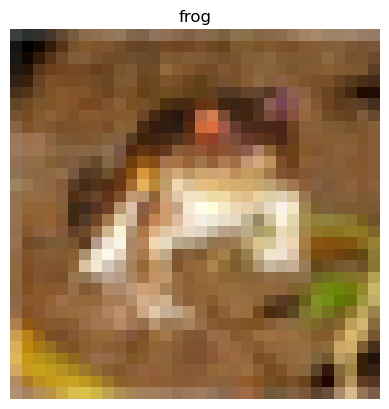

In [44]:
# Transform: convert images to PyTorch tensors
transform = transforms.ToTensor()

# Training dataset
trainset = torchvision.datasets.CIFAR10(root="./data",train=True,download=True,transform=transform)

# Test dataset
testset = torchvision.datasets.CIFAR10(root="./data",train=False,download=True,transform=transform)

# Data loaders
trainloader = torch.utils.data.DataLoader(trainset,batch_size=64,shuffle=True)

testloader = torch.utils.data.DataLoader(testset,batch_size=64,shuffle=False)

print(f"Training images: {len(trainset)}")
print(f"Test images: {len(testset)}")

# CIFAR-10 class names
classes = ("airplane", "automobile", "bird", "cat", "deer","dog", "frog", "horse", "ship", "truck")

image, label = trainset[0]
print(image.shape) # torch.Size([3, 32, 32])
print(classes[label])


# Get one image
image, label = trainset[0]

# Convert from (C, H, W) to (H, W, C)
image = image.permute(1, 2, 0)

# Plot
plt.imshow(image)
plt.title(classes[label])
plt.axis("off")
plt.show()

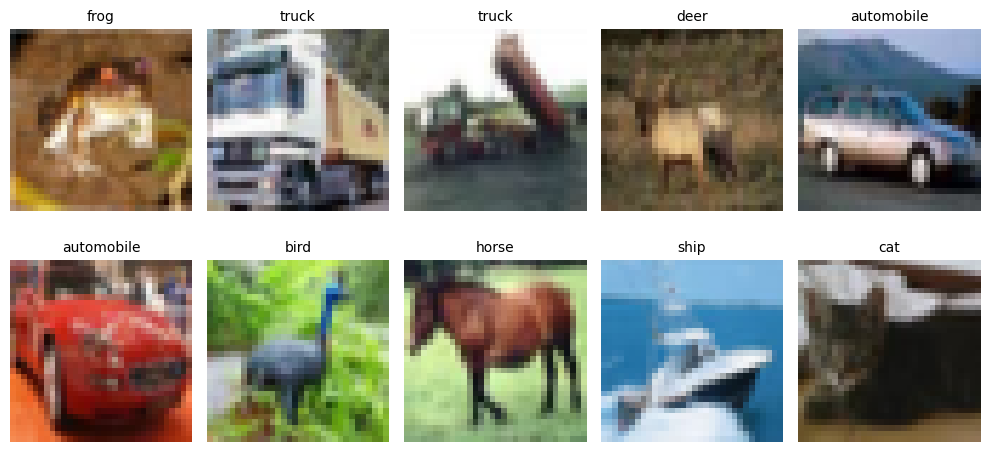

In [47]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    image, label = trainset[i]
    ax.imshow(image.permute(1, 2, 0))
    ax.set_title(classes[label], fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [48]:
# image.shape -> torch.Size([3, 32, 32])
# image[0] -> Red channel (32×32 matrix)
# image[1] -> Green channel (32×32 matrix)
# image[2] -> Blue channel (32×32 matrix)

image, label = trainset[0]

print("Red channel:")
print(image[0])

print("\nGreen channel:")
print(image[1])

print("\nBlue channel:")
print(image[2])

Red channel:
tensor([[0.2314, 0.1686, 0.1961,  ..., 0.6196, 0.5961, 0.5804],
        [0.0627, 0.0000, 0.0706,  ..., 0.4824, 0.4667, 0.4784],
        [0.0980, 0.0627, 0.1922,  ..., 0.4627, 0.4706, 0.4275],
        ...,
        [0.8157, 0.7882, 0.7765,  ..., 0.6275, 0.2196, 0.2078],
        [0.7059, 0.6784, 0.7294,  ..., 0.7216, 0.3804, 0.3255],
        [0.6941, 0.6588, 0.7020,  ..., 0.8471, 0.5922, 0.4824]])

Green channel:
tensor([[0.2431, 0.1804, 0.1882,  ..., 0.5176, 0.4902, 0.4863],
        [0.0784, 0.0000, 0.0314,  ..., 0.3451, 0.3255, 0.3412],
        [0.0941, 0.0275, 0.1059,  ..., 0.3294, 0.3294, 0.2863],
        ...,
        [0.6667, 0.6000, 0.6314,  ..., 0.5216, 0.1216, 0.1333],
        [0.5451, 0.4824, 0.5647,  ..., 0.5804, 0.2431, 0.2078],
        [0.5647, 0.5059, 0.5569,  ..., 0.7216, 0.4627, 0.3608]])

Blue channel:
tensor([[0.2471, 0.1765, 0.1686,  ..., 0.4235, 0.4000, 0.4039],
        [0.0784, 0.0000, 0.0000,  ..., 0.2157, 0.1961, 0.2235],
        [0.0824, 0.0000, 0.0314,

<a class="anchor" id="py"></a>

# 10. CNN PyTorch

<a class="anchor" id="tensor"></a>

# 11. CNN TensorFlow